In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

#Definición de la función para calcular la divergencia KL entre dos distribuciones discretas
def kl_discrete(p, q):
    """
    Calcula la divergencia Kullback-Leibler (KL) entre dos distribuciones de probabilidad discretas.

    Args:
        p (np.array): Distribución de probabilidad "verdadera" o empírica.
        q (np.array): Distribución de probabilidad "aproximada" o modelo.

    Returns:
        float: La divergencia KL.
    """
    # Asegurar que las distribuciones son arrays de numpy
    p = np.asarray(p)
    q = np.asarray(q)

    # Evitar logaritmos de cero; reemplazar valores cero con un número muy pequeño
    # para evitar divisiones por cero en q y log(0) en p. log(0) debería dar infinito.
    # Para la KL divergencia, si p(i) > 0 y q(i) = 0, la KL divergencia es infinita.
    # Aquí, simplemente filtramos los puntos donde p es cero o q es cero para el cálculo.
    # Una aproximación común es añadir un pequeño epsilon, pero para p log (p/q),
    # si p_i es 0, el término es 0. Si q_i es 0, el término es infinito si p_i > 0.
    # Usaremos una máscara para solo considerar los elementos donde p > 0 y q > 0
    mask = (p > 0) & (q > 0)
    if not np.all(mask):
        print("Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.")

    return np.sum(p[mask] * np.log(p[mask] / q[mask]))

import numpy as np

def entropy_discrete(p):
    """
    Calcula la entropía de Shannon de una distribución discreta.

    H(p) = - sum_i p_i log(p_i)

    Args:
        p (np.array): Arreglo de probabilidades.

    Returns:
        float: Entropía de Shannon.
    """
    p = np.asarray(p, dtype=float)

    mask = p > 0

    return -np.sum(p[mask] * np.log(p[mask]))


def cross_entropy_discrete(p, q):
    """
    Calcula la entropía cruzada entre dos distribuciones discretas.

    H(p, q) = - sum_i p_i log(q_i)

    Args:
        p (np.array): Distribución real.
        q (np.array): Distribución empírica.

    Returns:
        float: Entropía cruzada.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if np.any((p > 0) & (q == 0)):
        print("Advertencia: q tiene ceros donde p > 0. La entropía cruzada es infinita.")
        return np.inf

    mask = p > 0
    print(p,q)
    return -np.sum(p[mask] * np.log(q[mask]))

Vamos a lanzar un dado num_thorws veces. Esto nos permitirá calcular la probabilidad empírica y la compararemos con la distribución teórica. Se podrá observar que a medida que hay más datos, la probabilidad empírica será más cercana (distancia que tiende a 0). 

In [5]:
# 1. Simular 20 lanzamientos de un dado de 6 caras
num_throws = 1000
die_rolls = np.random.randint(1, 7, num_throws) # Dado de 6 caras (1 a 6)
#print(f"Lanzamientos del dado ({num_throws}): {die_rolls}")

# 2. Calcular la probabilidad experimental
# Contar las ocurrencias de cada cara
counts = pd.Series(die_rolls).value_counts().sort_index()

# Asegurarse de que todas las caras (1-6) estén presentes, incluso si no aparecieron
all_faces = np.arange(1, 7)
experimental_counts = counts.reindex(all_faces, fill_value=0)

# Calcular probabilidades experimentales
experimental_probs = experimental_counts / num_throws

print("\nProbabilidad experimental:")
print(experimental_probs)

# 3. Definir la distribución uniforme teórica para un dado de 6 caras
uniform_probs = np.full(6, 1/6)

print("\nProbabilidad uniforme teórica:")
print(uniform_probs)

# 4. Calcular la distancia de KL
kl_divergence = kl_discrete(experimental_probs.values, uniform_probs)

print(f"\nDistancia de KL (Experimental vs Uniforme): {kl_divergence:.6f}")


Probabilidad experimental:
1    0.173
2    0.181
3    0.151
4    0.189
5    0.163
6    0.143
Name: count, dtype: float64

Probabilidad uniforme teórica:
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]

Distancia de KL (Experimental vs Uniforme): 0.004719


 40%|████      | 10/25 [00:00<00:00, 97.53it/s]

Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.
Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.
Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.
Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.
Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.
Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.
Advertencia: Algunos valores en p o q son cero. La divergencia KL puede ser infinita o aproximada.


100%|██████████| 25/25 [00:00<00:00, 94.65it/s]


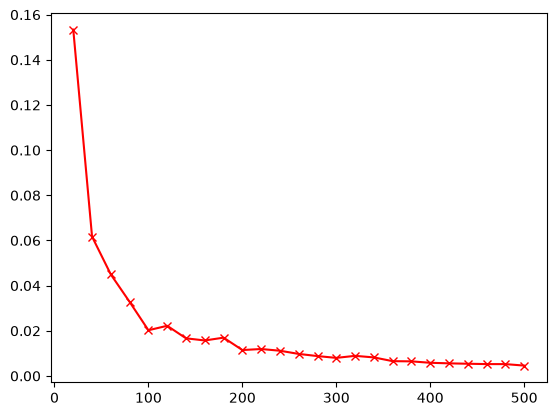

In [10]:
# Miremos cómo a medida que aumentamos el número de lanzamientos, la distancia KL debería acercarse a cero, 
# indicando que la distribución experimental se aproxima a la distribución uniforme teórica.
num=[int(ni) for ni in np.arange(20, 510, 20)]
KL=[]
for n in tqdm(num):
    #Repetición del experimento 10 veces para poder promediar la distancia KL y obtener un resultado más estable
    kl_divergences = []
    for _ in range(50):
        # 1. Simular 20 lanzamientos de un dado de 6 caras
        num_throws = n
        die_rolls = np.random.randint(1, 7, num_throws) # Dado de 6 caras (1 a 6)
        counts = pd.Series(die_rolls).value_counts().sort_index()
        all_faces = np.arange(1, 7)
        experimental_counts = counts.reindex(all_faces, fill_value=0)
        experimental_probs = experimental_counts / num_throws
        uniform_probs = np.full(6, 1/6)
        kl_divergence = kl_discrete(experimental_probs.values, uniform_probs)
        kl_divergences.append(kl_divergence)
    KL.append(np.mean(kl_divergences))
plt.plot(num,KL, 'x-r')

In [57]:
#Miremos ahora la relación entre la entropía cruzada y la distancia KL. Recordemos que la entropía cruzada H(p,q) se puede expresar como:
num_throws = 40
die_rolls = np.random.randint(1, 7, num_throws) # Dado de 6 caras (1 a 6)
counts = pd.Series(die_rolls).value_counts().sort_index()
all_faces = np.arange(1, 7)
experimental_counts = counts.reindex(all_faces, fill_value=0)
experimental_probs = experimental_counts / num_throws
print("\nProbabilidad experimental:")
print(experimental_probs)
uniform_probs = np.full(6, 1/6)
print("\nProbabilidad uniforme teórica:")
print(uniform_probs)
kl_divergence = kl_discrete(uniform_probs, experimental_probs.values)
print(f"\nDistancia de KL (Experimental vs Uniforme): {kl_divergence:.6f}")

#Entropia cruzada entre las dos distribuciones
cross_entropy = cross_entropy_discrete(uniform_probs, experimental_probs.values)
print(f"\nEntropía cruzada (Experimental vs Uniforme): {cross_entropy:.6f}")

#Entropia de la distribución teórica
entropy_uniform = entropy_discrete(uniform_probs)
print(f"\nEntropía de la distribución uniforme: {entropy_uniform:.6f}")

print('Revisemos la expresión de la entropía cruzada en términos de la entropía y la divergencia KL:')
print('H(p, q) = H(p) + D_KL(p || q)')
cross_entropy_check = entropy_uniform + kl_divergence
print(f"\nH(p) + D_KL(p || q) = {cross_entropy_check:.6f}")


Probabilidad experimental:
1    0.125
2    0.125
3    0.250
4    0.125
5    0.225
6    0.150
Name: count, dtype: float64

Probabilidad uniforme teórica:
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]

Distancia de KL (Experimental vs Uniforme): 0.043806
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667] [0.125 0.125 0.25  0.125 0.225 0.15 ]

Entropía cruzada (Experimental vs Uniforme): 1.835566

Entropía de la distribución uniforme: 1.791759
Revisemos la expresión de la entropía cruzada en términos de la entropía y la divergencia KL:
H(p, q) = H(p) + D_KL(p || q)

H(p) + D_KL(p || q) = 1.835566
